In [1]:
import frc
import numpy as np
import matplotlib.pyplot as plt
from tifffile import imread
from pathlib import Path

DIPlib -- a quantitative image analysis library
Version 3.5.0 (Jun 18 2024)
For more information see https://diplib.org


In [2]:
def crop_center(img,crop_size):

    if type(crop_size) == tuple:
        crop_x,crop_y = crop_size
    elif type(crop_size) == int:
        crop_x = crop_size
        crop_y = crop_size
    
    y,x = img.shape[-2::]
    startx = x//2-(crop_x//2)
    starty = y//2-(crop_y//2)        

    return img[...,starty:starty+crop_y,startx:startx+crop_x]

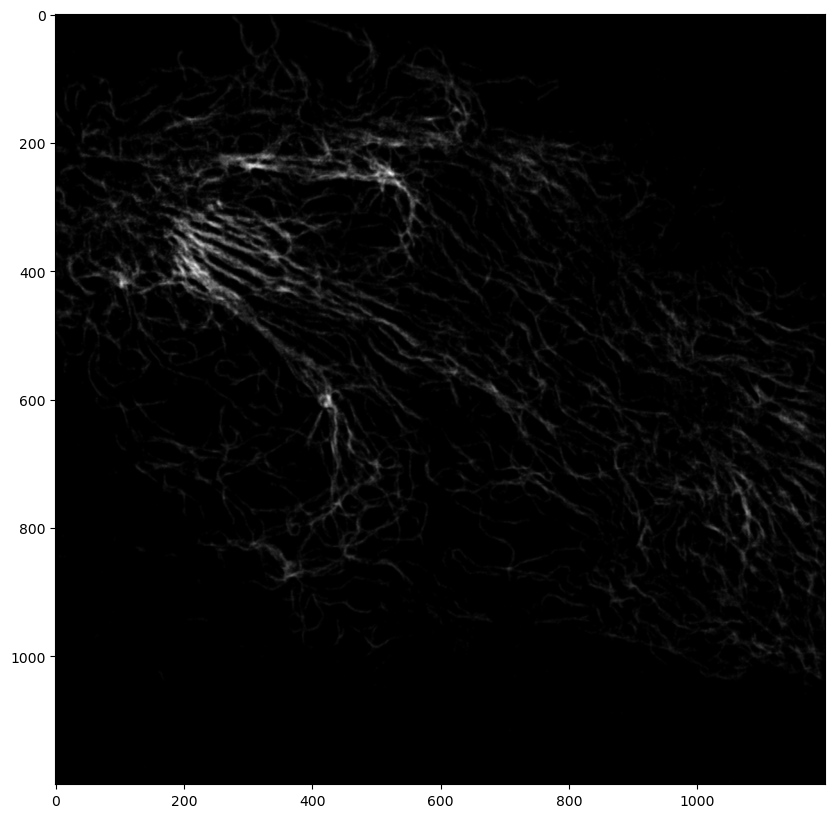

In [10]:
import os

stack_path = r'\\storage3.ad.scilifelab.se\testalab\Guillaume\01_Projects\DL_monalisa\_paper\Upsampling_Technical\fixed_snr\FRC\img_1_pred.tif'
gt_path = r'\\storage3.ad.scilifelab.se\testalab\Guillaume\01_Projects\DL_monalisa\_paper\Upsampling_Technical\fixed_snr\FRC\img_1_gt.tif'
gt = imread(gt_path)
stack = imread(stack_path)
bic = stack[2]
rcan = stack [0]
unet = stack[1]
plt.figure(figsize=(10,10))
plt.imshow(unet,cmap='gray')
plt.show()

In [11]:
# Process each image stack
data_list = [gt,rcan,unet]
all_frc_curves = []
for data in data_list:
    img = data - np.min(data)
    img = frc.util.apply_tukey(img)
    frc_curve,_,_ = frc.one_frc(img)
    frc_curve = (frc_curve - np.min(frc_curve)) / (np.max(frc_curve) - np.min(frc_curve))
    all_frc_curves.append(frc_curve)

all_frc_curves = np.stack(all_frc_curves)
print(all_frc_curves.shape)

(3, 600)


IndexError: index 3 is out of bounds for axis 0 with size 3

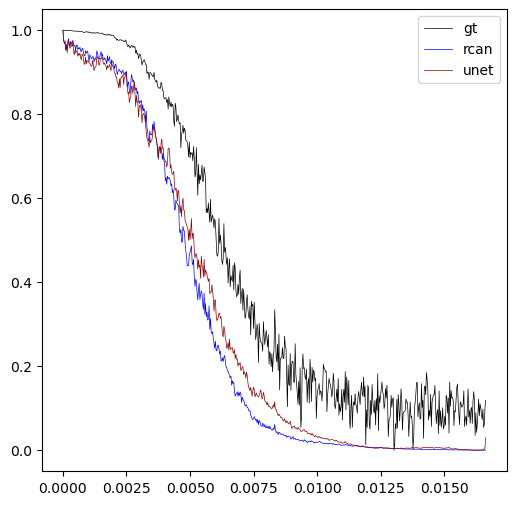

In [12]:
scale = 1/30# scale has units [pixels <length unit>^-1] corresponding to original image
img_size = img.shape[0]

labels = ["gt","rcan","unet"]
colors = ['black','blue', 'darkred', 'forestgreen']
# Mean FRC plot
fig, axs = plt.subplots(1, figsize=(6, 6))
for i in range(4): 
    frc_curve = all_frc_curves[i]
    xs_pix = np.arange(len(frc_curve)) / img_size
    xs_nm_freq = xs_pix * scale
    axs.plot(xs_nm_freq, frc_curve,label=labels[i],linewidth=0.5,color=colors[i])
    axs.legend()

plt.show()


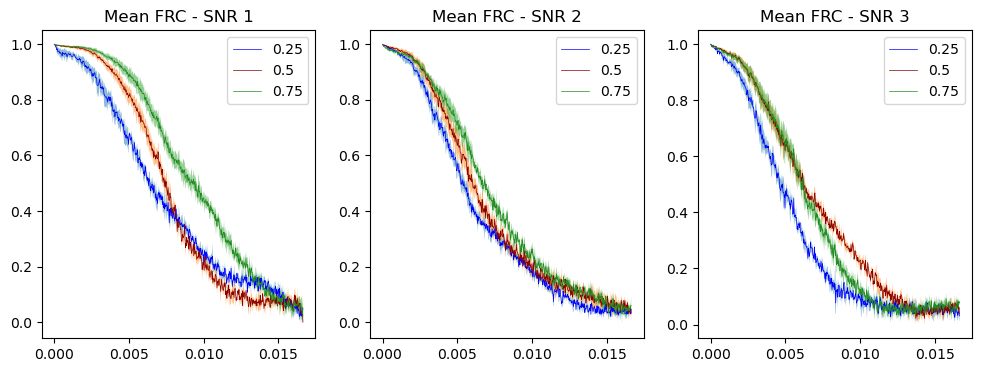

In [83]:

# FRC plot for each image
# fig, axs = plt.subplots(3, 3, figsize=(12, 12))
# for img_idx in range(all_frc_curves.shape[0]):
#     for i,snr in enumerate(snrs):
#         axs[img_idx,i].set_title(f"Img{img_idx} FRC - SNR {snr}")
#         for j,ff in enumerate(ffs):
#             idx = i * len(ffs) + j
#             frc_curve = all_frc_curves[img_idx,idx]
#             xs_pix = np.arange(len(frc_curve)) / img_size
#             xs_nm_freq = xs_pix * scale
#             axs[img_idx,i].plot(xs_nm_freq, frc_curve,label=ff,linewidth=0.7,color=colors[j])
#         axs[img_idx,i].legend()


# plt.show()

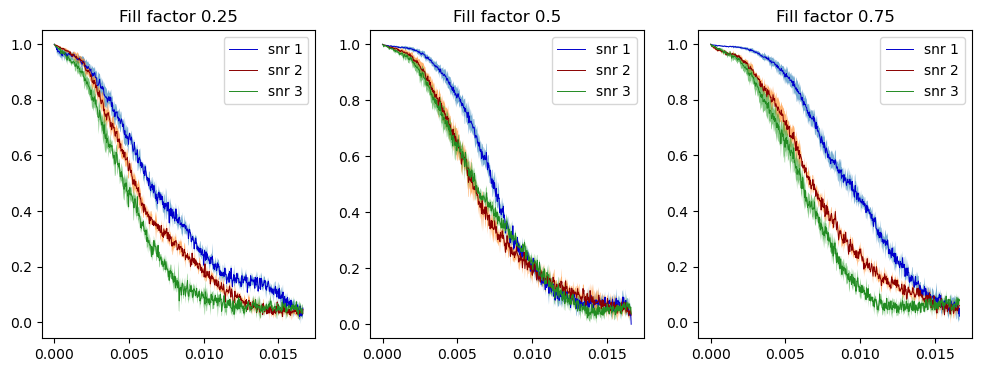

In [63]:
# Plot FRC vs ff for each SNR

# Mean FRC plot
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
for i,ff in enumerate(ffs):
    axs[i].set_title(f"Fill factor {ff}")
    for j,snr in enumerate(ffs):
        idx = i + (len(ffs)*(j))
        frc_curve = avg_frc_curves[idx]
        std_curve = std_frc_curves[idx]

        xs_pix = np.arange(len(frc_curve)) / img_size
        xs_nm_freq = xs_pix * scale
        axs[i].plot(xs_nm_freq, frc_curve,label=f"snr {snr}",linewidth=0.7,color=colors[j])
        axs[i].fill_between(xs_nm_freq, frc_curve - std_curve, frc_curve + std_curve, alpha=0.6)
    axs[i].legend()

plt.show()

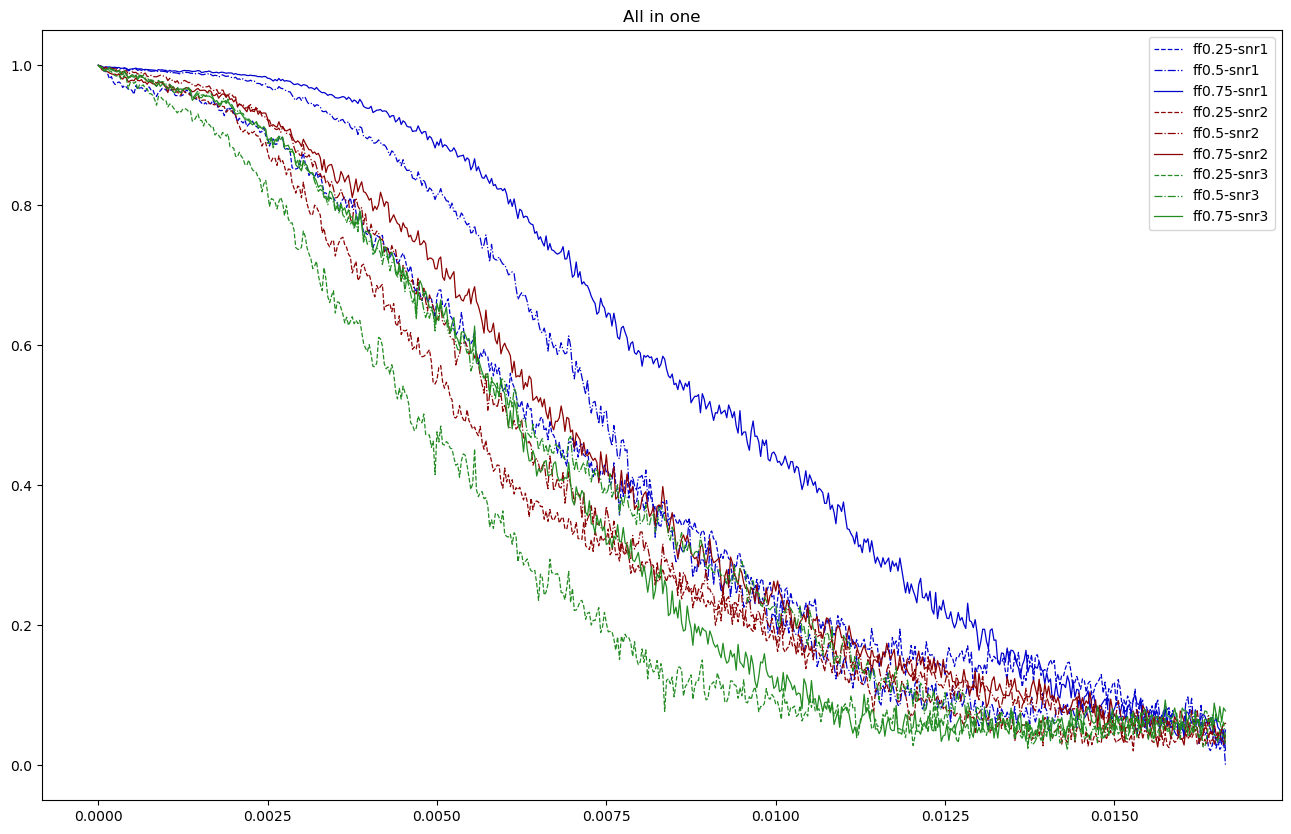

In [72]:
# Plot all in one

scale = 1/30# scale has units [pixels <length unit>^-1] corresponding to original image
img_size = gt.shape[0]

colors = ['mediumblue', 'darkred', 'forestgreen']
markers = ['+', 'o', 'x']
lines = [
    'dashed',
    'dashdot',
    'solid',
]
plt.figure(figsize=(16, 10))
for i,snr in enumerate(snrs):
    plt.title(f"All in one")
    for j,ff in enumerate(ffs):
        idx = i * len(ffs) + j
        frc_curve = avg_frc_curves[idx]
        xs_pix = np.arange(len(frc_curve)) / img_size
        xs_nm_freq = xs_pix * scale
        plt.plot(xs_nm_freq, frc_curve,label=f"ff{ff}-snr{snr}",color=colors[i],linestyle=lines[j],linewidth=0.9)

plt.legend()
plt.show()

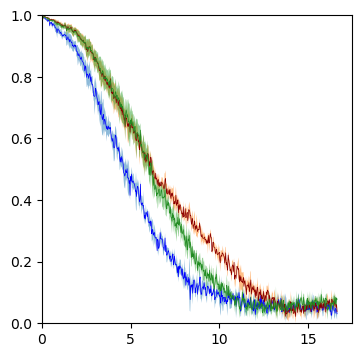

In [108]:
# Save figure for SNR avg only


scale = 1/30*1e3# scale has units [pixels <length unit>^-1] corresponding to original image

colors = ['blue', 'darkred', 'forestgreen']
# Mean FRC plot
fig = plt.figure(figsize=(4, 4))
for j,ff in enumerate(ffs):
    idx = 2 * len(ffs) + j
    frc_curve = avg_frc_curves[idx]
    std_curve = std_frc_curves[idx]

    xs_pix = np.arange(len(frc_curve)) / img_size
    xs_nm_freq = xs_pix * scale
    plt.plot(xs_nm_freq, frc_curve,label=ff,linewidth=0.5,color=colors[j])
    plt.fill_between(xs_nm_freq, frc_curve - std_curve, frc_curve + std_curve, alpha=0.5)
    plt.xlim(0)
    plt.xticks(range(0, 16, 5))
    plt.ylim(0,1)
plt.show()

save_folder = Path(r"\\storage3.ad.scilifelab.se\testalab\Guillaume\01_Projects\DL_monalisa\_paper\Upsampling_charac\fixed_snr")

fig.savefig(save_folder/"FRC_snr1_3ff.svg", format="svg", bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

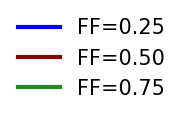

In [106]:
# save legend

from matplotlib.lines import Line2D
fig = plt.figure()
legend_lines = [Line2D([0], [0], color=colors[idx], lw=3) for idx in range(len(ffs))]

# Create a figure for the legend (without axes)
fig = plt.figure(figsize=(2, 1)) 
ax = fig.add_subplot(111)  
ax.set_axis_off()
ax.legend(legend_lines, [f'FF={ff:.2f}' for ff in ffs],
          loc='center', framealpha=1, frameon=False, fontsize=15)

# Remove ticks and labels
ax.set_xticks([])
ax.set_yticks([])
plt.show()

# Save the legend as an SVG
fig.savefig(save_folder/'legend_fill_factor_tight.svg', format='svg', bbox_inches='tight', pad_inches=0.1,transparent=True)